Abstract 
 
This test involves the motion detection of fixed CCTV traffic footage in seperating the moving vehicles on the lanes from the static background environment/landscape. Two approaches will be used in order to fulfil the test and both will be compared, a simple frame differencing method and a model-based MOG2 background subtraction technique. Each method will be applied to the same footage and the results will be evaulated qualitatively based on how clearly and accurately they can detect motion, showcasing the advantages and limitations of each.

Problem Statement 

Seperating moving objects from a static background is essential in video surveillance, traffic monitoring, and wildlife observation, the more clarity in the seperation, the better, as shadows, changes in light, any extra background motion can reduce the clarity, and therefore the accuracy. This test will compare a simple frame differencing approach with whats considered to be a stronger model-based MOG2 background subtractor to evalute how effectively these two can identify moving objects. The goal is to understand the advantages and limitations of each method in handling real-world video footage and seeing which is best when it comes to motion detection.

Initialisation

In [12]:
import cv2
import numpy as np

cap = cv2.VideoCapture(
    "C:\\Users\\igash\\Documents\\GitHub\\DIG5125-Image-Video-Processing\\Data\\Videos\\traffic.mp4"
)

fps = cap.get(cv2.CAP_PROP_FPS)
delay = int(1000 / fps)

ret, prev_frame = cap.read()
if not ret:
    print("Failed to read video")
    cap.release()
    exit()

prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

# Morphology kernel
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))

# MOG2 initialisation
bg_subtractor = cv2.createBackgroundSubtractorMOG2(
    history=500,
    varThreshold=16,
    detectShadows=True
)

Main Loop

In [13]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Method 1: Frame Differencing
    frame_diff = cv2.absdiff(prev_gray, gray)
    blurred_fd = cv2.GaussianBlur(frame_diff, (5, 5), 0)
    _, motion_fd = cv2.threshold(blurred_fd, 40, 255, cv2.THRESH_BINARY)

    # Method 2: MOG2 
    fg_mask = bg_subtractor.apply(frame)
    _, fg_mask = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)
    motion_mog2 = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)

    # Visual Comparison 
    cv2.imshow("Original Video", frame)
    cv2.imshow("Method 1: Frame Differencing", motion_fd)
    cv2.imshow("Method 2: MOG2 Background Subtraction", motion_mog2)

    prev_gray = gray

    if cv2.waitKey(delay) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Performance analysis:
To analyse the performance of the motion detection methods, the two techniques were applied to the same footage in order to compare the effectiveness of each. Quantitative metrics such as precision and recall require ground truth segmentation masks which aren't available for this dataset. So the emphasis is on qualitative evaluation alone.

Simple Motion Detection VS Model-based Motion Detection

Frame differencing which is a simple motion detection method identifies motion by subtracting frames from eachother but this means it can be sensitive to noise, lighting changes, and camera shake, which can cause obscurity and false positives.

MOG2 background subtraction is a model-based method meaning it builds a model of the background over time which makes it better equipped to handle changes in lighting and shadows but if the background is too dynamic it can struggle.

Optical flow is another motion detection method which is more detailed as it estimates movement on a pixel level but for real-time use its not as reliable.

Qualitative Results

Frame Differencing 

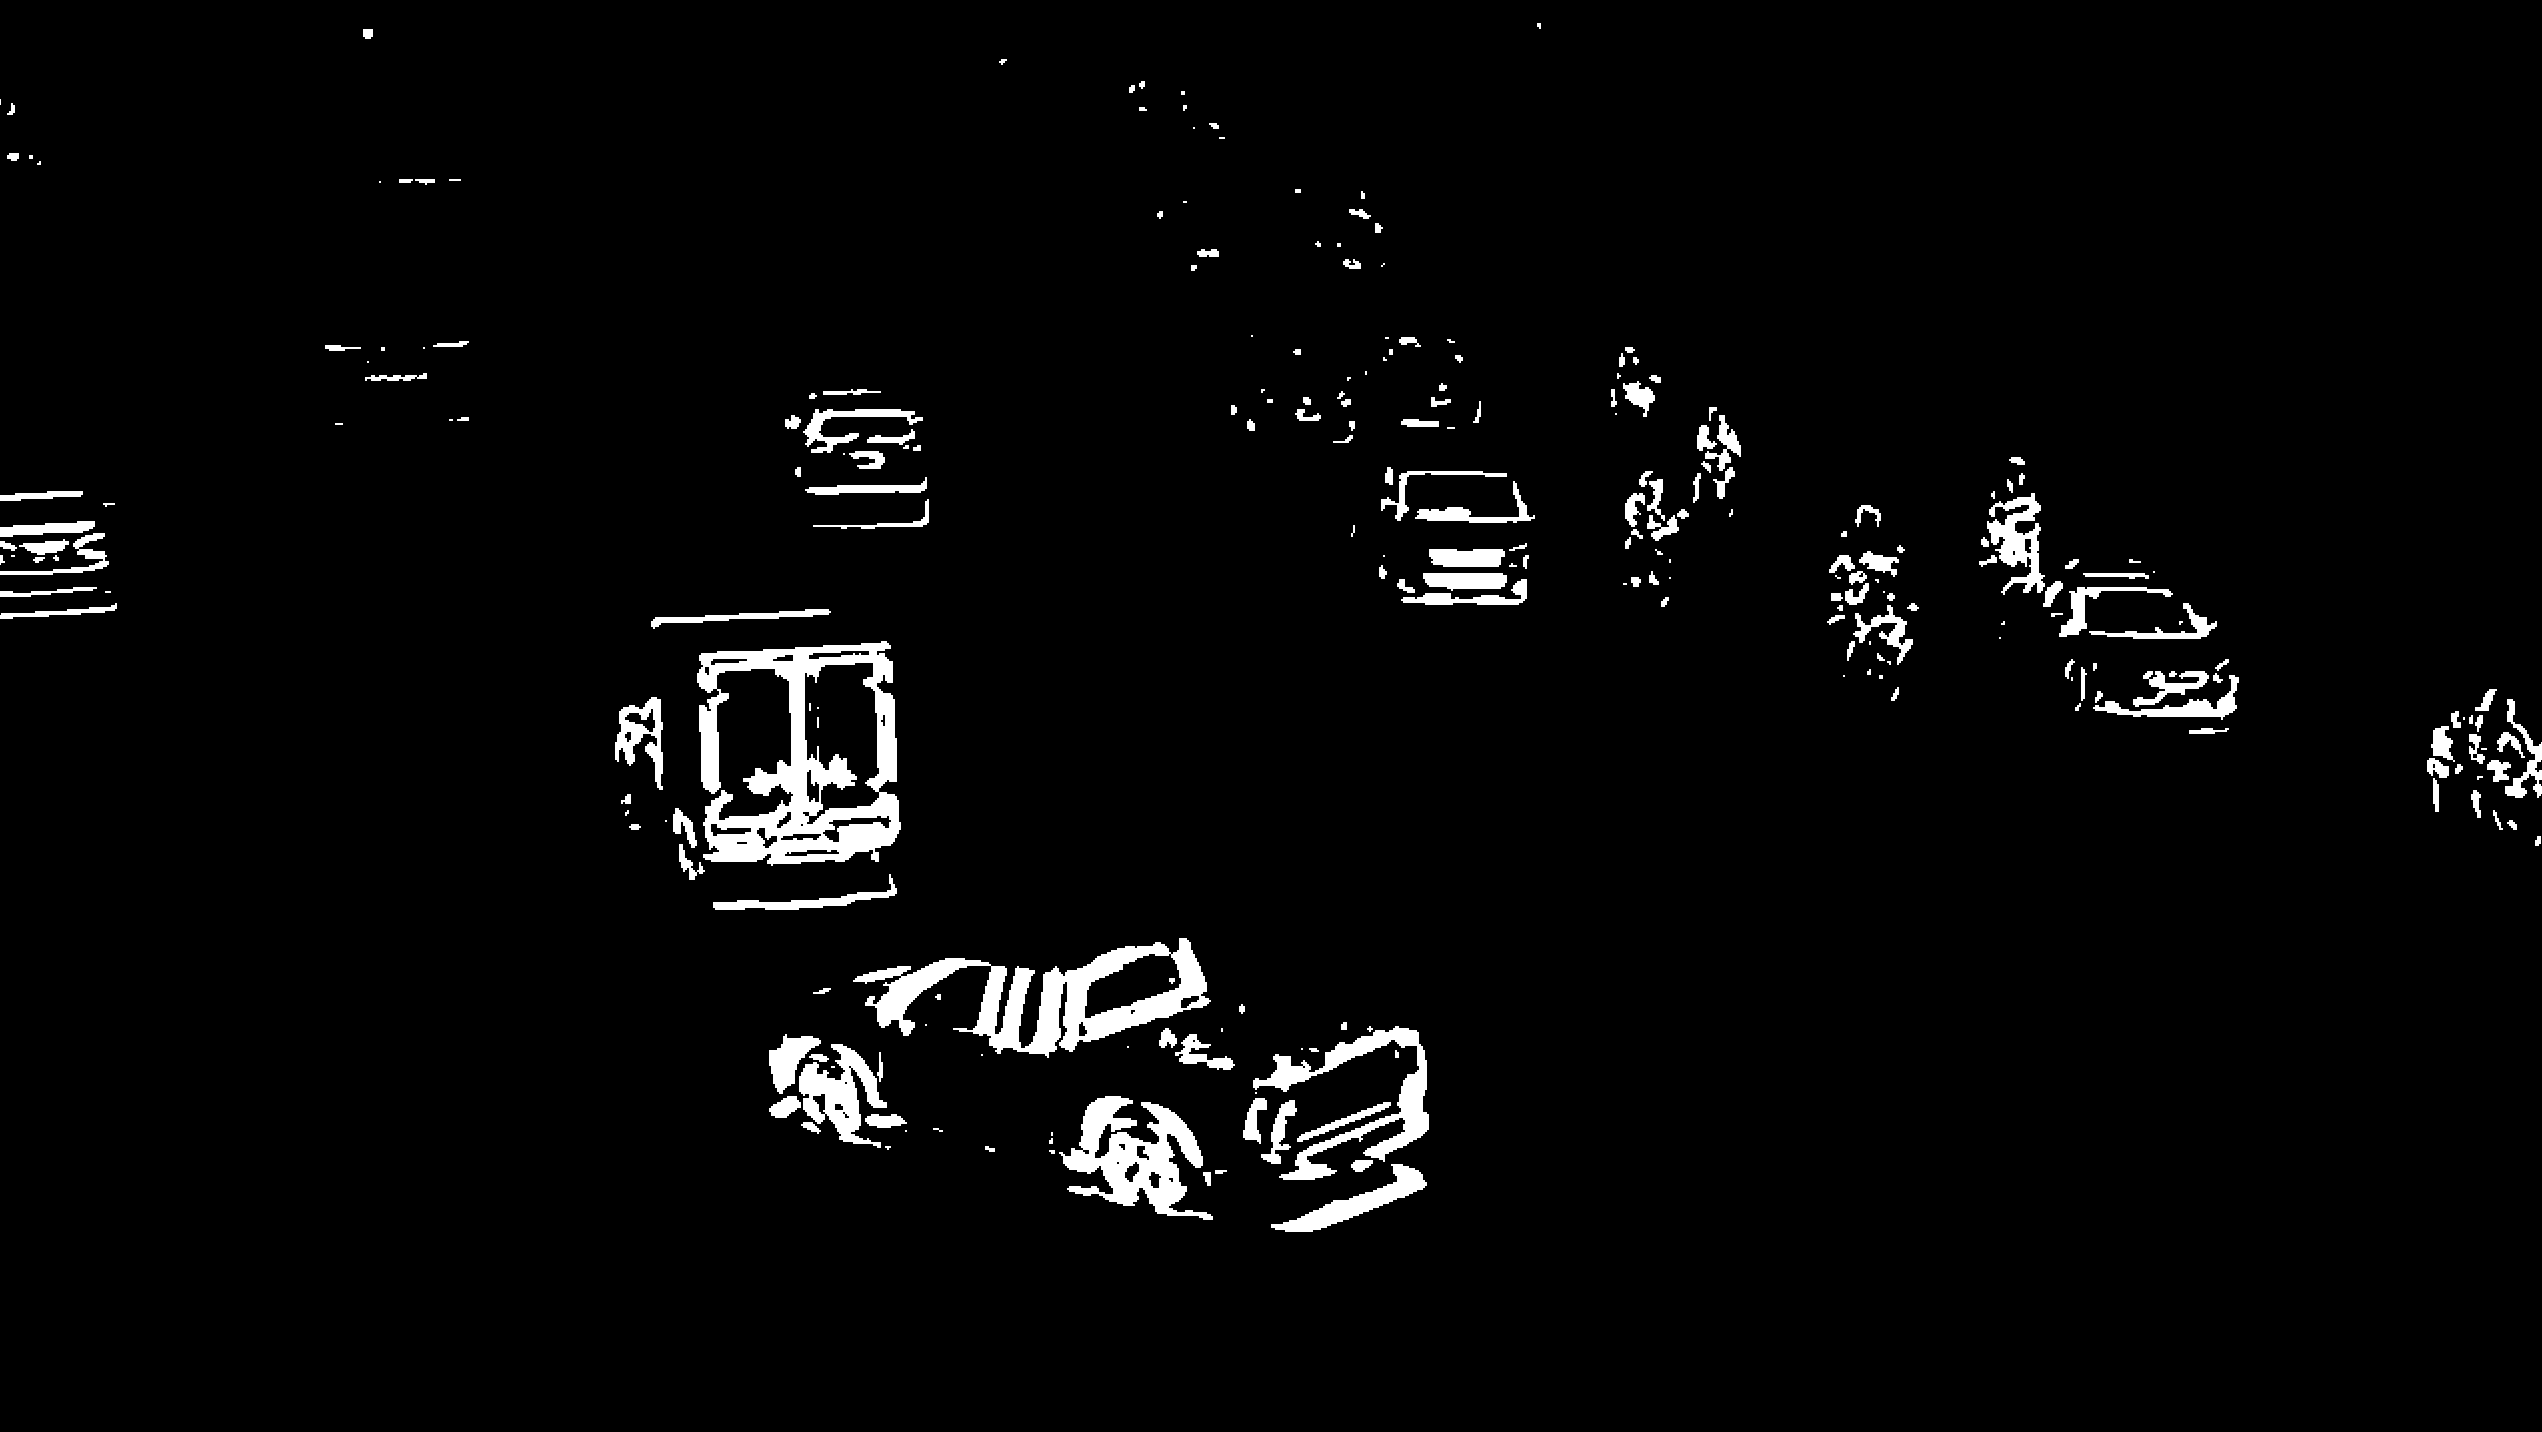

MOG2

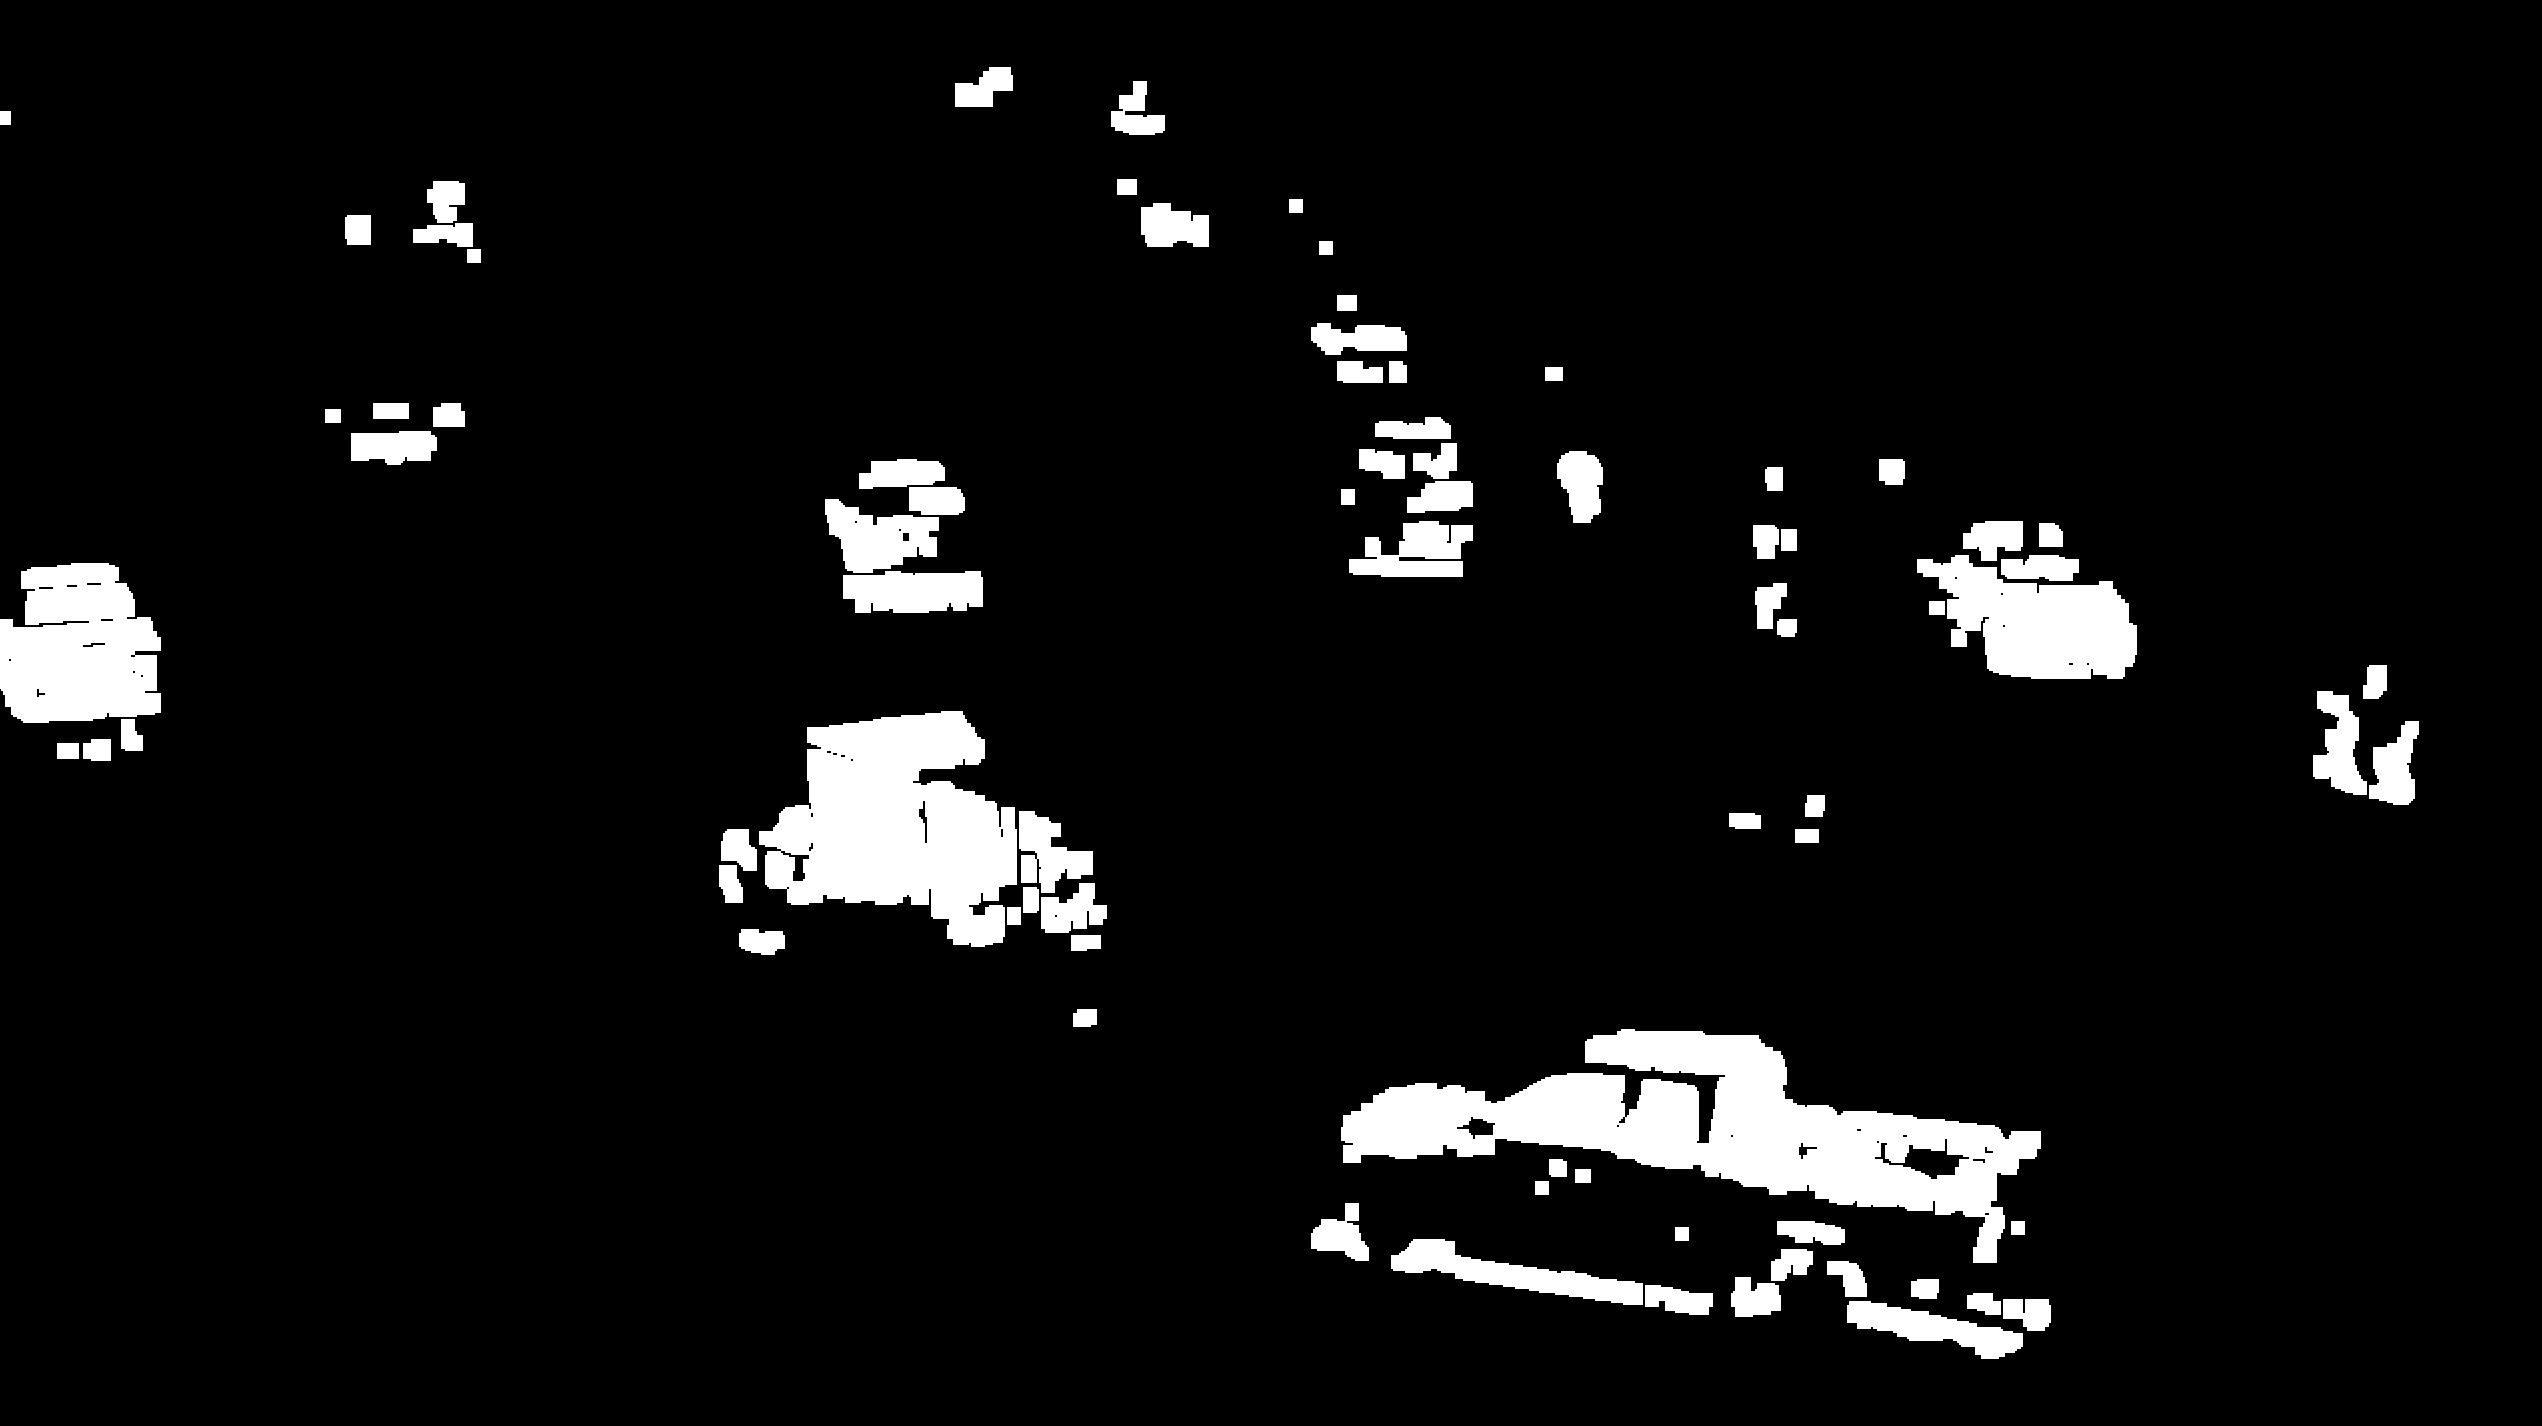

Frame Differencing looks more detailed as the edges are clearly defined so you can identify specific vehicles more effectively whereas MOG2 just replaces the vehicles with blobs so each vehicle is harder to identify, a positive of MOG2 however is that there is no stutter visually it looks smoother overall with less choppiness so if something could happen in a split second it can be identified whereas with frame differencing whatever could happen in a split second could be missed if it occurs during a stutter which occurs consistently and isn't a one off thing. Overall though, frame differencing is better because its more digestible visual-wise.

Qualitative Limitations

Again, varying percepetion, eye-sight, devices, display settings, monitor sizes, can play a part in varying qualitative results, however this is to a lesser extent as the two methods are very much defined and identifiable for what they are.

Journal References:

Zivkovic, Z. (2004). Improved adaptive Gaussian mixture model for background subtraction. Proceedings of ICPR.
- Introduces the MOG-based background modelling approach.

OpenCV Documentation. Background Subtraction (MOG2).
- Discusses implementation details and parameter explanations.

Gonzalez, R. C., & Woods, R. E. Digital Image Processing. Pearson.
- Covers frame differencing and motion detection fundamentals.